In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

In [2]:
reg_df = pd.read_csv('/content/sample_data/Movie_regression.csv')
clf_df = pd.read_csv('/content/sample_data/Movie_classification.csv')

# Decision Tree Regressor

In [ ]:
reg_df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400


In [ ]:
reg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

In [ ]:
reg_df.describe()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.391498,260.832095,39.181818,545.043478,45057.707510
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.295161,104.779133,12.513697,106.332889,18364.351764
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,10000.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.300000,223.796000,28.000000,465.000000,34050.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,160.000000,254.400000,39.000000,535.500000,42400.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.890000,283.416000,50.000000,614.750000,50000.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,100000.000000


In [ ]:
reg_df.isnull().sum()

,0
Marketing expense,0
Production expense,0
Multiplex coverage,0
Budget,0
Movie_length,0
Lead_ Actor_Rating,0
Lead_Actress_rating,0
Director_rating,0
Producer_rating,0
Critic_rating,0


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
reg_df['Time_taken'] = imputer.fit_transform(reg_df[['Time_taken']])

In [3]:
Xr = pd.get_dummies(reg_df.drop("Collection", axis=1), drop_first=True)
yr = reg_df["Collection"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = dt_reg.predict(X_test)

In [ ]:
r2_score(y_test, y_pred)

0.847424484345604

In [ ]:
mean_absolute_error(y_test, y_pred)

5207.843137254902

In [ ]:
mean_squared_error(y_test, y_pred)

45006274.50980392

In [ ]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(6708.671590546367)

In [ ]:
print("Train R²:", dt_reg.score(X_train, y_train))
print("Test R² :", dt_reg.score(X_test, y_test))

Train R²: 1.0
Test R² : 0.847424484345604


In [ ]:
dt_reg.get_depth()

20

In [ ]:
dt_reg.get_n_leaves()

np.int64(379)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

for depth in [3, 5, 7, 10, 15, 20]:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    print(
        f"Depth={depth}",
        f"Train R²={model.score(X_train, y_train):.4f}",
        f"Test R²={model.score(X_test, y_test):.4f}"
    )

Depth=3 Train R²=0.8307 Test R²=0.8197
Depth=5 Train R²=0.9180 Test R²=0.8668
Depth=7 Train R²=0.9602 Test R²=0.8652
Depth=10 Train R²=0.9900 Test R²=0.8400
Depth=15 Train R²=0.9997 Test R²=0.8189
Depth=20 Train R²=1.0000 Test R²=0.8099


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
y_pred = dt_reg.predict(X_test)

In [ ]:
print("Train R²:", dt_reg.score(X_train, y_train))
print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train R²: 0.9179888786867687
Test R²: 0.8667885749046195
MAE: 5102.3958808447605
RMSE: 6268.517554231434


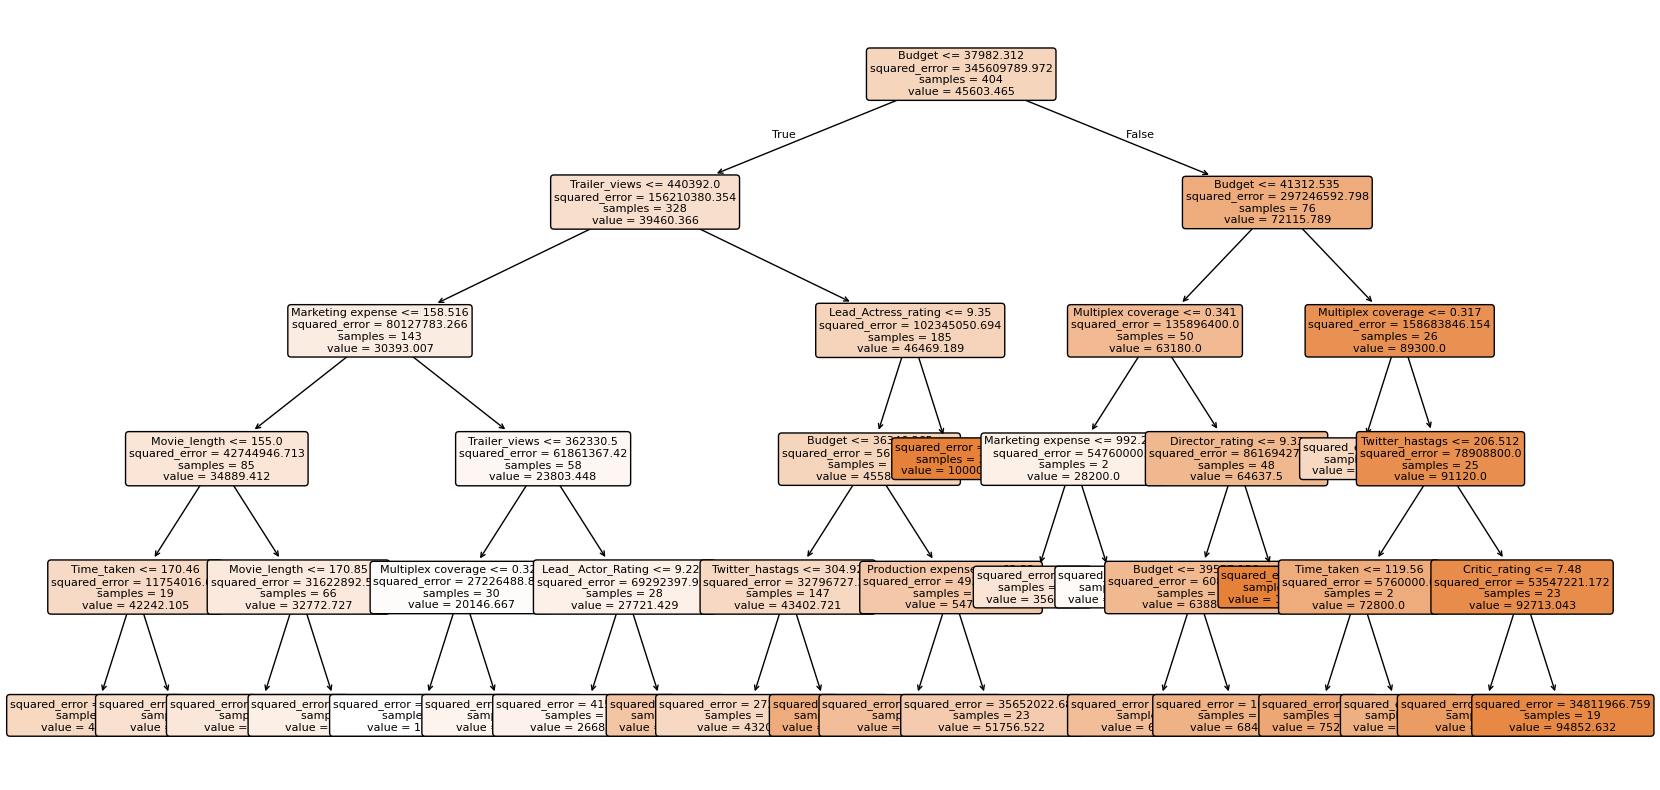

In [ ]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt_reg, filled=True, rounded=True, feature_names=X_train.columns, fontsize=8)
plt.show()

# Decision Tree Classifier

In [ ]:
clf_df.head()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


In [ ]:
clf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

In [ ]:
clf_df.describe()

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,494.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,92.270471,77.273557,0.445305,34911.144022,142.074901,8.014002,8.185613,8.019664,8.190514,7.810870,449860.715415,157.391498,260.832095,39.181818,545.043478,45057.707510,0.545455
std,172.030902,13.720706,0.115878,3903.038232,28.148861,1.054266,1.054290,1.059899,1.049601,0.659699,68917.763145,31.295161,104.779133,12.513697,106.332889,18364.351764,0.498422
min,20.126400,55.920000,0.129000,19781.355000,76.400000,3.840000,4.035000,3.840000,4.030000,6.600000,212912.000000,0.000000,201.152000,3.000000,333.000000,10000.000000,0.000000
25%,21.640900,65.380000,0.376000,32693.952500,118.525000,7.316250,7.503750,7.296250,7.507500,7.200000,409128.000000,132.300000,223.796000,28.000000,465.000000,34050.000000,0.000000
50%,25.130200,74.380000,0.462000,34488.217500,151.000000,8.307500,8.495000,8.312500,8.465000,7.960000,462460.000000,160.000000,254.400000,39.000000,535.500000,42400.000000,1.000000
75%,93.541650,91.200000,0.551000,36793.542500,167.575000,8.865000,9.030000,8.883750,9.030000,8.260000,500247.500000,181.890000,283.416000,50.000000,614.750000,50000.000000,1.000000
max,1799.524000,110.480000,0.615000,48772.900000,173.500000,9.435000,9.540000,9.425000,9.635000,9.400000,567784.000000,217.520000,2022.400000,60.000000,868.000000,100000.000000,1.000000


In [ ]:
clf_df.isnull().sum()

,0
Marketing expense,0
Production expense,0
Multiplex coverage,0
Budget,0
Movie_length,0
Lead_ Actor_Rating,0
Lead_Actress_rating,0
Director_rating,0
Producer_rating,0
Critic_rating,0


In [ ]:
clf_df.duplicated().sum()

np.int64(0)

In [8]:
Xc = pd.get_dummies(clf_df.drop("Start_Tech_Oscar", axis=1), drop_first=True)
yc = clf_df["Start_Tech_Oscar"]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
Xc["Time_taken"] = imputer.fit_transform(Xc[["Time_taken"]])

In [ ]:
Xc.isnull().sum()

,0
Marketing expense,0
Production expense,0
Multiplex coverage,0
Budget,0
Movie_length,0
Lead_ Actor_Rating,0
Lead_Actress_rating,0
Director_rating,0
Producer_rating,0
Critic_rating,0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt_clf.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[24 18]
 [27 33]]


In [ ]:
accuracy_score(y_test, y_pred)

0.5588235294117647

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.57      0.52        42
           1       0.65      0.55      0.59        60

    accuracy                           0.56       102
   macro avg       0.56      0.56      0.56       102
weighted avg       0.57      0.56      0.56       102



In [ ]:
for depth in [2,3,4,5,6,7,8,10]:
    clf = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    clf.fit(X_train, y_train)

    print(
        f"Depth={depth}",
        f"Train={clf.score(X_train,y_train):.4f}",
        f"Test={clf.score(X_test,y_test):.4f}"
    )

Depth=2 Train=0.5941 Test=0.5294
Depth=3 Train=0.6238 Test=0.5588
Depth=4 Train=0.6337 Test=0.5588
Depth=5 Train=0.7129 Test=0.5000
Depth=6 Train=0.7450 Test=0.5784
Depth=7 Train=0.7574 Test=0.5784
Depth=8 Train=0.8094 Test=0.5098
Depth=10 Train=0.8812 Test=0.5392


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=6)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
y_pred = dt_clf.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[23 19]
 [24 36]]


In [ ]:
accuracy_score(y_test, y_pred)

0.5784313725490197

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.55      0.52        42
           1       0.65      0.60      0.63        60

    accuracy                           0.58       102
   macro avg       0.57      0.57      0.57       102
weighted avg       0.59      0.58      0.58       102



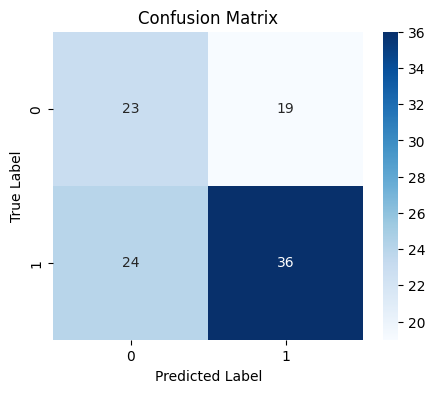

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

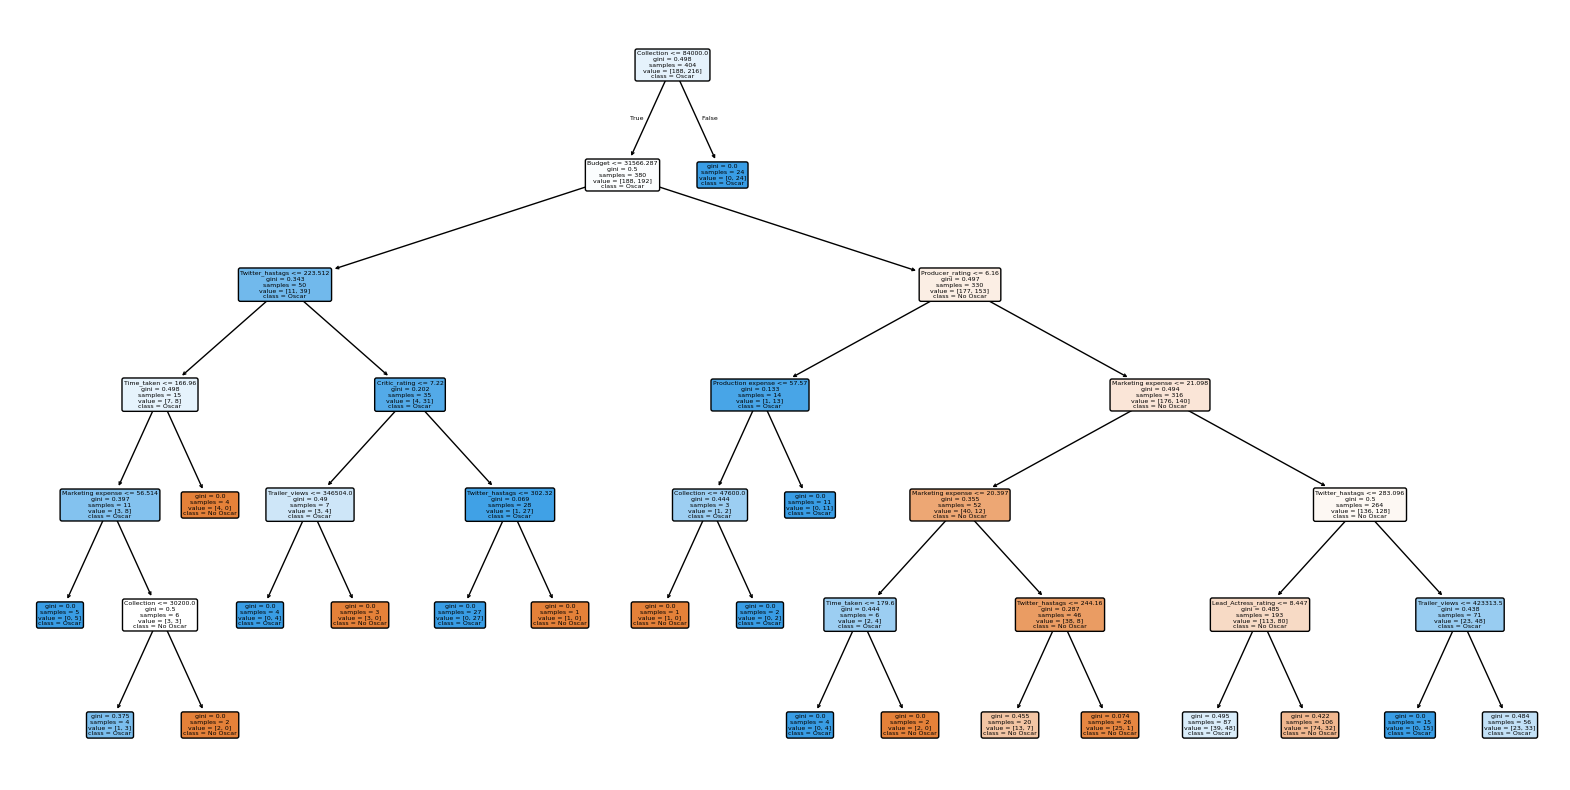

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_clf,
    feature_names=Xc.columns,
    class_names=["No Oscar", "Oscar"],
    filled=True,
    rounded=True
)

plt.show()

# Hyperparameter Tuning

## Descision Tree Classifier

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8,10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7, 8, 10],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score: 0.6188580246913581


In [ ]:
best_clf = grid_search.best_estimator_

y_pred = best_clf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5490196078431373
              precision    recall  f1-score   support

           0       0.47      0.64      0.54        42
           1       0.66      0.48      0.56        60

    accuracy                           0.55       102
   macro avg       0.56      0.56      0.55       102
weighted avg       0.58      0.55      0.55       102



## Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_reg = DecisionTreeRegressor(random_state=42)

grid_reg = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_reg.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7, 8, 10],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='r2')

In [ ]:
print("Best Parameters:", grid_reg.best_params_)
print("Best CV R²:", grid_reg.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV R²: 0.04537835436200808


In [ ]:
best_reg = grid_reg.best_estimator_

y_pred = best_reg.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Test R²: 0.017884402091003615
MAE: 0.4437855310900732


# XGBoost

## XGBoost Regression

In [5]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42)
xgb_reg.fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)

In [6]:
print("Train R²:", xgb_reg.score(X_train, y_train))
print("Test R² :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Train R²: 0.9975416660308838
Test R² : 0.8953226804733276
MAE : 3978.90771484375
MSE : 30877400.0
RMSE: 5556.743650736464


## XGBoost Classification

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [10]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
y_pred = xgb_clf.predict(X_test)

In [12]:
print("Train Accuracy:", xgb_clf.score(X_train, y_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy : 0.6274509803921569
[[23 19]
 [19 41]]
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        42
           1       0.68      0.68      0.68        60

    accuracy                           0.63       102
   macro avg       0.62      0.62      0.62       102
weighted avg       0.63      0.63      0.63       102



## GridSearchCV

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [50, 100, 200]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",      # use "accuracy" for classifier
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best CV Score: 0.0725013017654419
